In [2]:
import pandas as pd
import numpy as np

In [51]:
df = pd.read_csv("../data/insurance.csv")

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


 Features
 1.age
 2.sex
 3.bmi
 4.children
 5.smoker
 6.region
 7.charges
 target : charges


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


### numerical feature :
1. age
2. bmi
3. children
4. charges 

### categorical feature :
1. sex
2. smoker
3. region 


In [6]:
df.shape

(1338, 7)

1338 rows , 7 colums 


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

these exist no null values


In [8]:
df.duplicated() 

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [9]:
df[df.duplicated()]


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


only one duplicate entry so we can drop it 

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df[df.duplicated()]


,age,sex,bmi,children,smoker,region,charges


dupliactes removed successfully 

In [12]:
df.describe()


,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


Age:
    The insured individuals range from 18 to 64 years old, indicating that the dataset covers a broad adult population. The mean age (39.22) is very close to the median age (39), suggesting that the age distribution is approximately symmetric.

Bmi:
    BMI values range from 15.96 to 53.13. The average BMI is approximately 30.66, which indicates that many individuals fall into the overweight category.

children:
    The number of children ranges from 0 to 5. The average number of children is approximately 1, indicating that most policyholders have few dependents.
    

charges:
    Insurance charges vary considerably, ranging from 1,121 to 63,770. The mean charge (13,279) is substantially higher than the median charge (9,386), indicating that the distribution is likely right-skewed. This suggests the presence of a small number of individuals with exceptionally high medical costs.

Dataset Name: Medical Insurance Cost Prediction

Rows: 1338
Columns: 7

Target Variable:
- charges

Numerical Features:
- age
- bmi
- children
- charges

Categorical Features:
- sex
- smoker
- region

Missing Values:
- None

Duplicate Values:
- 1
Removed duplicate values 
- done

Rows: 1337
Columns: 7


Initial Observation:
- Dataset contains both numerical and categorical data.
- contains independent features and dependent feature(charge)
- charge is a continious varible 
- Suitable for Linear Regression.

# Univariate Analyis

In [13]:
categorical_cols = df.select_dtypes(include="object").columns

numerical_cols = df.select_dtypes(exclude="object").columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='str')

Numerical Columns:
Index(['age', 'bmi', 'children', 'charges'], dtype='str')


C:\Users\vasanth Jp\AppData\Local\Temp\ipykernel_4436\9874586.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [14]:
import matplotlib.pyplot as plt
    

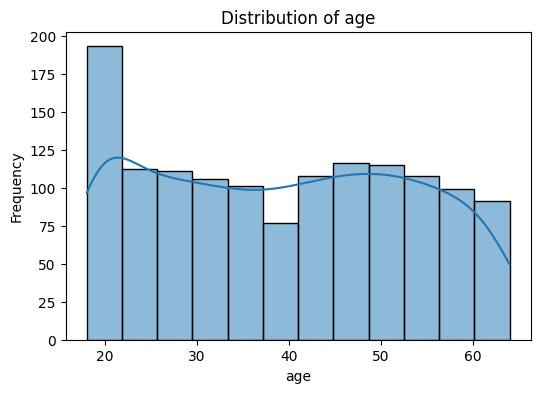

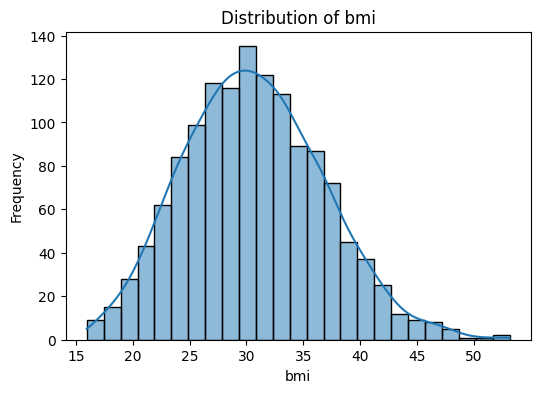

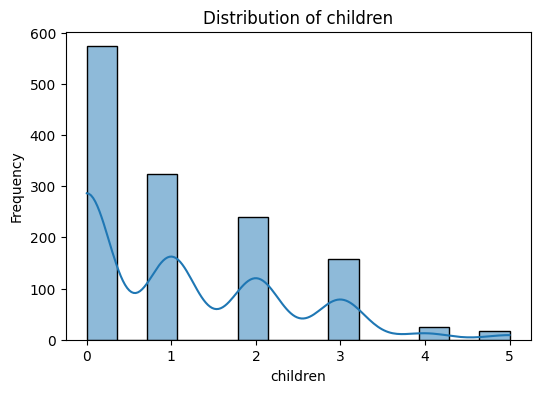

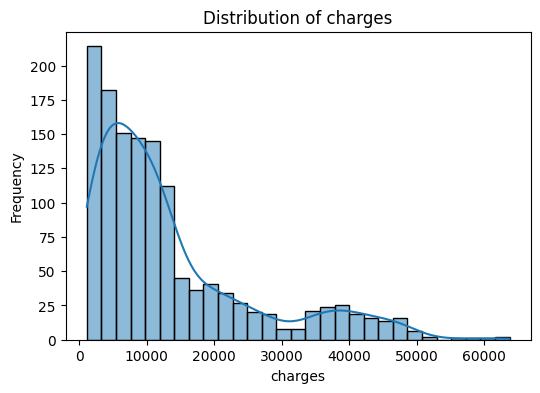

In [15]:
import seaborn as sns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

1. age -> approximately uniform 
2. bmi -> mostly between 25 to 35 approximately normal
3. charges -> strongly right skewed (only less frequency of people have taken more charges
)

<Axes: xlabel='children', ylabel='count'>

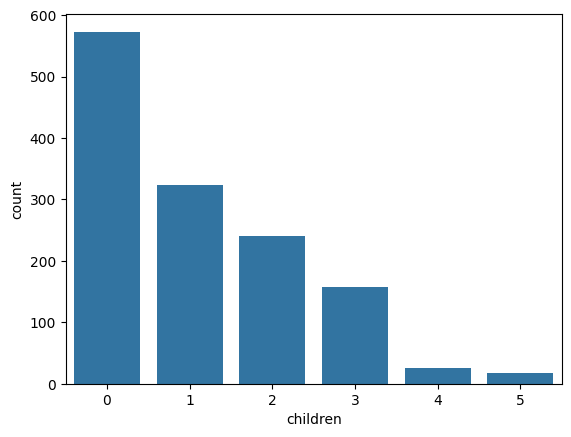

In [16]:
sns.countplot(data=df,x='children')


In [17]:
df["children"].value_counts()

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

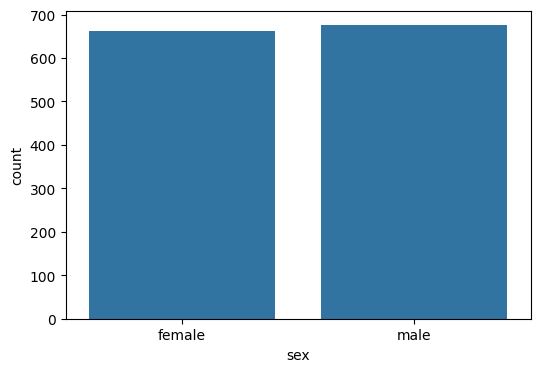

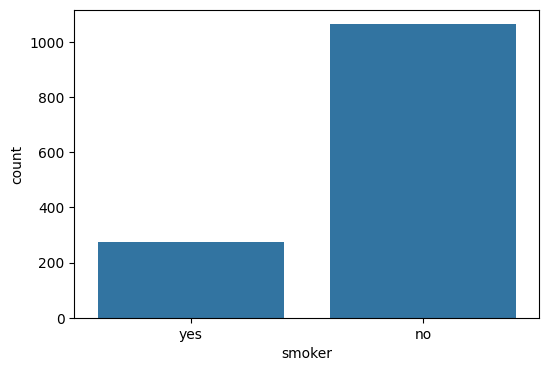

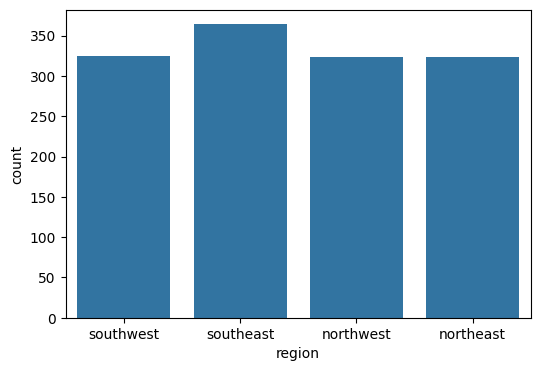

In [18]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df,x=col)
    plt.show()

sex:
    both male and female population is balanced in the dataset
smokers:
    most of the population is non smokers
region:
    a fair distribution of data form all regions 
    

# bivariate analysis


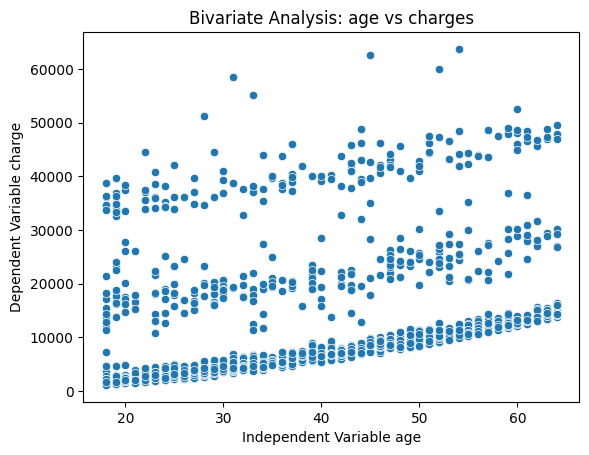

In [19]:
# Create the scatter plot with a linear regression trend line
sns.scatterplot(x='age', y='charges', data=df)

plt.title('Bivariate Analysis: age vs charges')
plt.xlabel('Independent Variable age')
plt.ylabel('Dependent Variable charge')
plt.show()


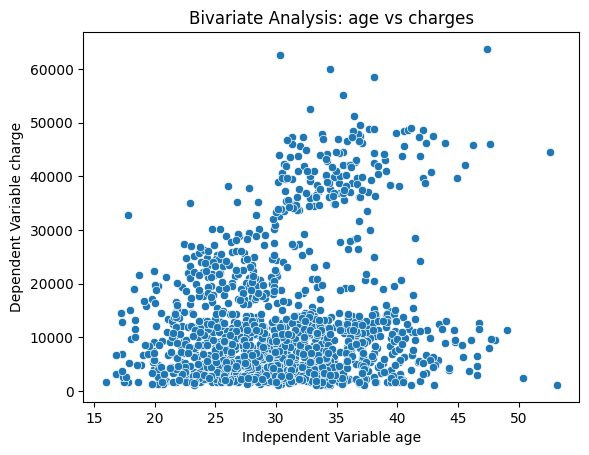

In [20]:
sns.scatterplot(x='bmi', y='charges', data=df)

plt.title('Bivariate Analysis: age vs charges')
plt.xlabel('Independent Variable age')
plt.ylabel('Dependent Variable charge')
plt.show()

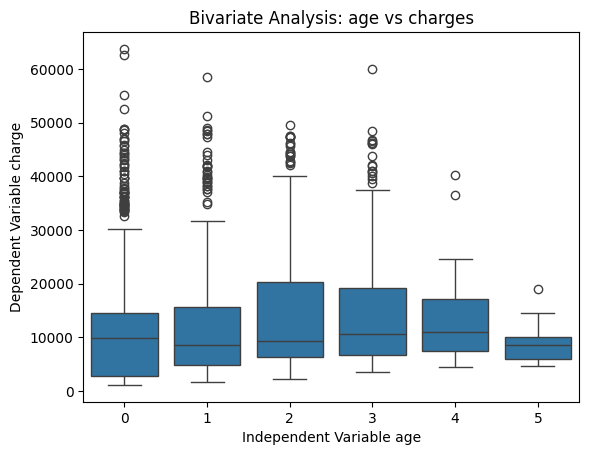

In [21]:
sns.boxplot(x='children', y='charges', data=df)

plt.title('Bivariate Analysis: age vs charges')
plt.xlabel('Independent Variable age')
plt.ylabel('Dependent Variable charge')
plt.show()

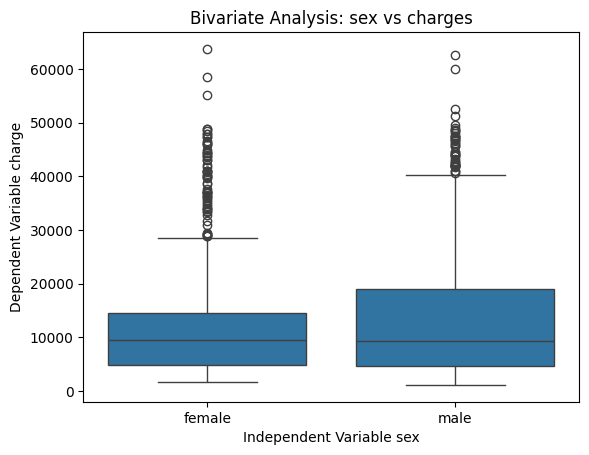

In [22]:
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Bivariate Analysis: sex vs charges')
plt.xlabel('Independent Variable sex')
plt.ylabel('Dependent Variable charge')
plt.show()

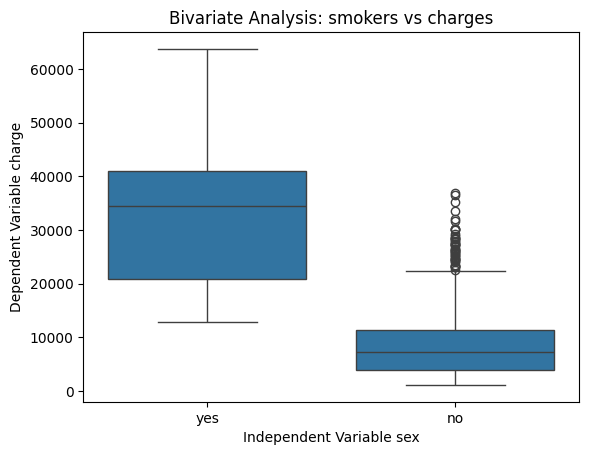

In [23]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Bivariate Analysis: smokers vs charges')
plt.xlabel('Independent Variable sex')
plt.ylabel('Dependent Variable charge')
plt.show()

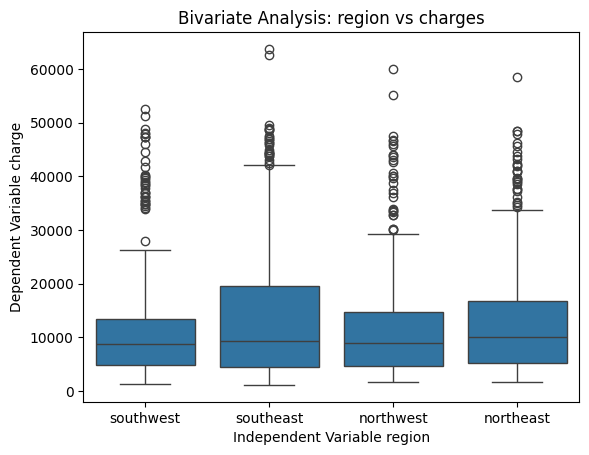

In [24]:
sns.boxplot(x='region', y='charges', data=df)
plt.title('Bivariate Analysis: region vs charges')
plt.xlabel('Independent Variable region')
plt.ylabel('Dependent Variable charge')
plt.show()

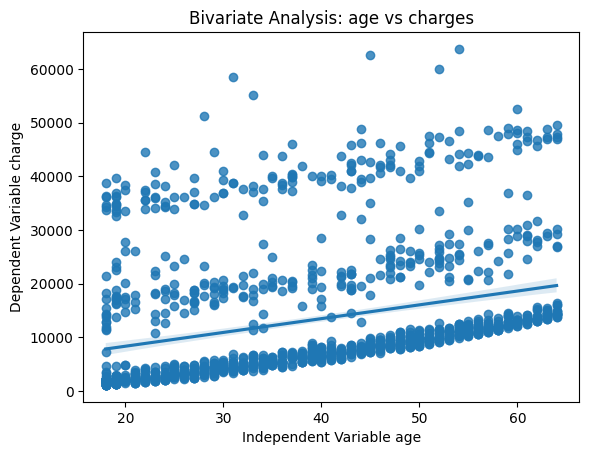

In [25]:
sns.regplot(x='age', y='charges', data=df)
plt.title('Bivariate Analysis: age vs charges')
plt.xlabel('Independent Variable age')
plt.ylabel('Dependent Variable charge')
plt.show()

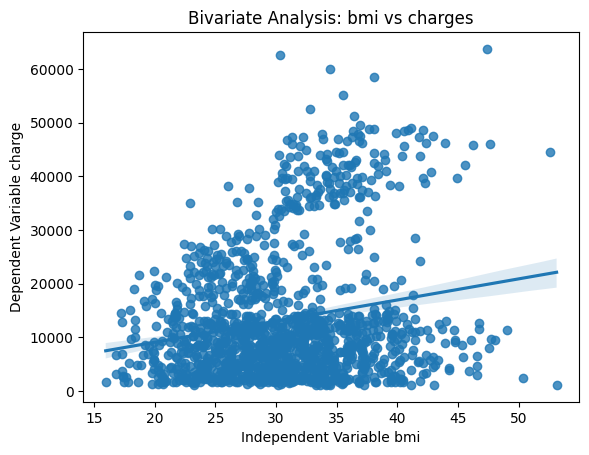

In [26]:
sns.regplot(x='bmi', y='charges', data=df)
plt.title('Bivariate Analysis: bmi vs charges')
plt.xlabel('Independent Variable bmi')
plt.ylabel('Dependent Variable charge')
plt.show()

In [27]:
corr = df[numerical_cols].corr()

<Axes: >

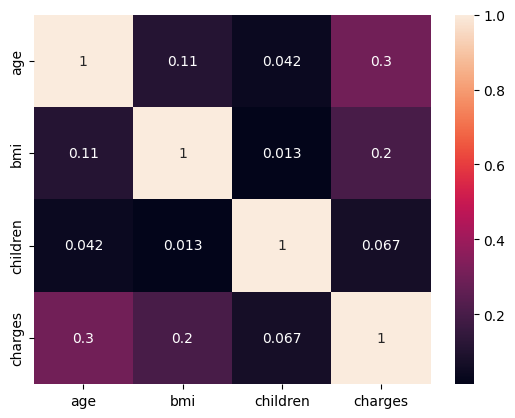

In [28]:
sns.heatmap(corr,annot=True)

Age and BMI exhibit the strongest positive relationships with insurance charges. Examination of the correlation matrix indicates that no pair of independent variables has a correlation coefficient exceeding the commonly used threshold of ±0.7. Therefore, there is no immediate evidence of severe multicollinearity among the numerical predictors.

# outlair analysis

In [29]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\nColumn: {column}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {len(outliers)}")

    return outliers

In [30]:
age_outliers = detect_outliers_iqr(df, 'age')


Column: age
Q1: 27.0
Q3: 51.0
IQR: 24.0
Lower Bound: -9.0
Upper Bound: 87.0
Number of Outliers: 0


In [31]:
bmi_outliers = detect_outliers_iqr(df, 'bmi')


Column: bmi
Q1: 26.29
Q3: 34.7
IQR: 8.410000000000004
Lower Bound: 13.674999999999994
Upper Bound: 47.31500000000001
Number of Outliers: 9


In [32]:
charges_outliers = detect_outliers_iqr(df, 'charges')


Column: charges
Q1: 4746.344
Q3: 16657.71745
IQR: 11911.37345
Lower Bound: -13120.716174999998
Upper Bound: 34524.777625
Number of Outliers: 139


In [33]:
bmi_outliers

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.32540
286,46,female,48.07,2,no,northeast,9432.92530
401,47,male,47.52,1,no,southeast,8083.91980
543,54,female,47.41,0,yes,southeast,63770.42801
847,23,male,50.38,1,no,southeast,2438.05520
860,37,female,47.60,2,yes,southwest,46113.51100
1047,22,male,52.58,1,yes,southeast,44501.39820
1088,52,male,47.74,1,no,southeast,9748.91060
1317,18,male,53.13,0,no,southeast,1163.46270


In [34]:
charges_outliers.head()


,age,sex,bmi,children,smoker,region,charges
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768
29,31,male,36.30,2,yes,southwest,38711.0000
30,22,male,35.60,0,yes,southwest,35585.5760


# feature Engineering 

In [35]:
X = df.drop('charges', axis=1)

y = df['charges']

In [36]:
X.head()


,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [37]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [38]:
X['sex'] = X['sex'].map({
    'male': 1,
    'female': 0
})

In [39]:
X['sex'].value_counts()

sex
1    675
0    662
Name: count, dtype: int64

In [40]:
X['smoker'] = X['smoker'].map({
    'yes': 1,
    'no': 0
})

In [41]:
X['smoker'].value_counts()

smoker
0    1063
1     274
Name: count, dtype: int64

In [42]:
X = pd.get_dummies(
    X,
    columns=['region'],
    drop_first=True
)

In [43]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,False,False,True
1,18,1,33.770,1,0,False,True,False
2,28,1,33.000,3,0,False,True,False
3,33,1,22.705,0,0,True,False,False
4,32,1,28.880,0,0,True,False,False


In [44]:
X.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   sex               1337 non-null   int64  
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   smoker            1337 non-null   int64  
 5   region_northwest  1337 non-null   bool   
 6   region_southeast  1337 non-null   bool   
 7   region_southwest  1337 non-null   bool   
dtypes: bool(3), float64(1), int64(4)
memory usage: 66.6 KB


In [45]:
X[['region_northwest',
   'region_southeast',
   'region_southwest']] = (
    X[['region_northwest',
       'region_southeast',
       'region_southwest']]
    .astype(int)
)

In [46]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,1
1,18,1,33.770,1,0,0,1,0
2,28,1,33.000,3,0,0,1,0
3,33,1,22.705,0,0,1,0,0
4,32,1,28.880,0,0,1,0,0


In [47]:
X.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   sex               1337 non-null   int64  
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   smoker            1337 non-null   int64  
 5   region_northwest  1337 non-null   int64  
 6   region_southeast  1337 non-null   int64  
 7   region_southwest  1337 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 94.0 KB


In [48]:
X.to_csv("processed_X.csv", index=False)
y.to_csv("target_y.csv", index=False)

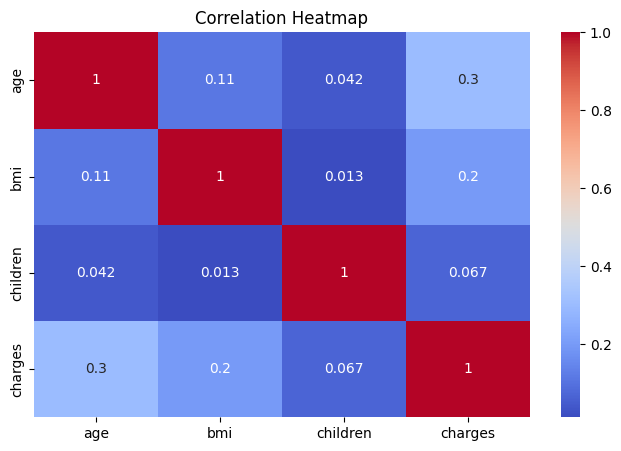

In [49]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png",
            bbox_inches="tight")

plt.show()

NameError: name 'y_pred' is not defined

<Figure size 800x500 with 0 Axes>